# Chapter 3(A): DeepSeekMoE - Environment Setup and Dependencies

In [1]:
# Install required libraries (-q = quiet installation output)
!pip install datasets tiktoken tqdm numpy matplotlib pandas -q


# ============================================================
# Import Core Libraries
# ============================================================

# Main PyTorch library for tensor operations and deep learning
import torch

# Neural network layers and modules
import torch.nn as nn

# Functional API (softmax, cross_entropy, gelu, etc.)
import torch.nn.functional as F

# Mathematical functions
import math

# Operating system utilities
import os

# Time measurement utilities
import time

# Context manager utility often used in mixed precision training
from contextlib import nullcontext

# Dataclass decorator for configuration classes
from dataclasses import dataclass

# Direct tensor constructor import
from torch import tensor


# ============================================================
# Data Loading and Tokenization Libraries
# ============================================================

# Numerical computing library
import numpy as np

# Hugging Face dataset loader
from datasets import load_dataset

# OpenAI tokenizer library
import tiktoken

# Progress bar utility
from tqdm.auto import tqdm


# ============================================================
# Visualization and Analysis Libraries
# ============================================================

# Plotting library
import matplotlib.pyplot as plt

# Data analysis library
import pandas as pd


# ============================================================
# Verify Installation
# ============================================================

# Print success message after imports
print("All dependencies installed and imported successfully.")


# ============================================================
# Check GPU Availability
# ============================================================

# Check whether CUDA GPU is available
if torch.cuda.is_available():

    # Display detected GPU name
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")

    # Display installed PyTorch version
    print(f"PyTorch version: {torch.__version__}")

    # Display CUDA version used by PyTorch
    print(f"CUDA version: {torch.version.cuda}")

else:

    # Fallback message when GPU is unavailable
    print("No GPU detected. Running on CPU.")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.26a0+c5e1555-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.0-py3.12.egg is depreca

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All dependencies installed and imported successfully.
GPU detected: NVIDIA B200 MIG 1g.23gb
PyTorch version: 2.7.0a0+7c8ec84dab.nv25.03
CUDA version: 12.8


# Global Training Configuration

In [2]:
# Number of training sequences processed together in one batch
BATCH_SIZE = 32

# Maximum number of tokens the model can see at once
# Also called context length or sequence length
BLOCK_SIZE = 256

# Total number of training iterations (optimization steps)
MAX_ITERS = 5000

# Evaluate training and validation loss every 250 iterations
EVAL_INTERVAL = 250

# Number of batches used to compute average validation loss
# Higher values give more stable loss estimates
EVAL_ITERS = 100

# Peak learning rate used by the optimizer
LEARNING_RATE = 3e-4

# Number of iterations used for learning rate warmup
# Learning rate gradually increases from 0 to LEARNING_RATE
WARMUP_ITERS = 200

# Minimum learning rate reached after cosine decay schedule
MIN_LR = 3e-5

# Device and Mixed Precision Configuration

In [3]:
# Automatically select GPU if available, otherwise use CPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Select training precision
# Use bfloat16 on supported GPUs (A100, H100, etc.)
# Otherwise use float16 for faster training and lower memory usage
DTYPE = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'

# Convert precision name into the corresponding PyTorch datatype
PTDTYPE = {
    'float16': torch.float16,
    'bfloat16': torch.bfloat16,
    'float32': torch.float32
}[DTYPE]

# Create automatic mixed-precision context
# CPU uses normal precision (nullcontext)
# GPU uses autocast to automatically perform operations in the selected precision
CTX = (
    nullcontext()
    if DEVICE == 'cpu'
    else torch.amp.autocast(
        device_type=DEVICE,
        dtype=PTDTYPE
    )
)

# GradScaler prevents gradient underflow during float16 training
# Not required for bfloat16 because bfloat16 has a larger exponent range
SCALER = torch.cuda.amp.GradScaler(
    enabled=(DTYPE == 'float16')
)

/tmp/ipykernel_1674/983724551.py:30: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  SCALER = torch.cuda.amp.GradScaler(


# Base Model Architecture Configuration

In [4]:
# Dataclass automatically creates an initialization method
# and stores all model hyperparameters in a single object
@dataclass
class BaseModelConfig:

    # Number of Transformer blocks/layers
    n_layer: int = 6

    # Number of attention heads in each Transformer block
    n_head: int = 8

    # Embedding dimension (hidden size / d_model)
    n_embd: int = 256

    # Vocabulary size used by GPT-2 tokenizer
    # GPT-2 contains 50,257 unique tokens
    vocab_size: int = 50257

    # Maximum sequence length (context window)
    block_size: int = BLOCK_SIZE

    # Dropout probability used during training
    dropout: float = 0.1

    # Whether Linear and LayerNorm layers use bias terms
    # False is common in modern Transformer implementations
    bias: bool = False

    # Compression ratio used by MLA (Multi-Head Latent Attention)
    # 0.5 means latent dimension is 50% of embedding dimension
    MLA_COMPRESSION_RATIO = 0.5

    # Latent dimension used by MLA
    # Formula:
    # d_latent = n_embd × MLA_COMPRESSION_RATIO
    # Example:
    # 256 × 0.5 = 128
    d_latent: int = int(256 * MLA_COMPRESSION_RATIO)

    # Number of dimensions dedicated to RoPE
    # Used by DeepSeek's positional attention path
    d_rope: int = 16

# Initialize Model Configuration

In [5]:
# Create an instance of the BaseModelConfig class
# This object stores all model hyperparameters
BASE_CONFIG = BaseModelConfig()

# Number of Key-Value groups used in Grouped Query Attention (GQA)
# Example:
# 8 query heads divided into 2 groups
GQA_N_GROUPS = 2

# Verify that the number of attention heads can be evenly divided
# among the GQA groups
#
# Example:
# 8 heads ÷ 2 groups = 4 heads per group ✓
assert BASE_CONFIG.n_head % GQA_N_GROUPS == 0, \
    "n_head must be divisible by n_groups for GQA"

# Display the selected compute device
print(f"Running on device: {DEVICE}")

# Display the selected numerical precision
print(f"Using data type: {DTYPE}")

# Display the main model architecture settings
print(
    f"Base model config: "
    f"{BASE_CONFIG.n_layer} layers, "
    f"{BASE_CONFIG.n_head} heads, "
    f"{BASE_CONFIG.n_embd} embedding dim."
)

Running on device: cuda
Using data type: bfloat16
Base model config: 6 layers, 8 heads, 256 embedding dim.


# Dataset and Tokenizer Configuration

In [6]:
# Hugging Face dataset name
# TinyStories is a small, high-quality text dataset
# commonly used for training and experimenting with LLMs
DATASET_NAME = "roneneldan/TinyStories"

# File name used to store tokenized training data
TRAIN_BIN_FILE = "train.bin"

# File name used to store tokenized validation data
VAL_BIN_FILE = "val.bin"

# Tokenizer model to use
# GPT-2 tokenizer contains a vocabulary of 50,257 tokens
TOKENIZER_MODEL = "gpt2"

In [7]:
from huggingface_hub import list_repo_files

print(list_repo_files(
    "roneneldan/TinyStories",
    repo_type="dataset"
)[:20])

['.gitattributes', 'Evaluation prompts.yaml', 'MLP_input_output.npy', 'README.md', 'TinyStories-train.txt', 'TinyStories-valid.txt', 'TinyStoriesV2-GPT4-train.txt', 'TinyStoriesV2-GPT4-valid.txt', 'TinyStories_all_data.tar.gz', 'data/train-00000-of-00004-2d5a1467fff1081b.parquet', 'data/train-00001-of-00004-5852b56a2bd28fd9.parquet', 'data/train-00002-of-00004-a26307300439e943.parquet', 'data/train-00003-of-00004-d243063613e5a057.parquet', 'data/validation-00000-of-00001-869c898b519ad725.parquet']


In [8]:
from huggingface_hub import hf_hub_download

train_file = hf_hub_download(
    repo_id="roneneldan/TinyStories",
    filename="TinyStories-train.txt",
    repo_type="dataset"
)

valid_file = hf_hub_download(
    repo_id="roneneldan/TinyStories",
    filename="TinyStories-valid.txt",
    repo_type="dataset"
)

print(train_file)
print(valid_file)

/root/.cache/huggingface/hub/datasets--roneneldan--TinyStories/snapshots/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/TinyStories-train.txt
/root/.cache/huggingface/hub/datasets--roneneldan--TinyStories/snapshots/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/TinyStories-valid.txt


In [9]:
from huggingface_hub import hf_hub_download

train_file = hf_hub_download(
    repo_id="roneneldan/TinyStories",
    filename="TinyStories-train.txt",
    repo_type="dataset"
)

with open(train_file, "r", encoding="utf-8") as f:
    print(f.read(500))

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.
Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."
Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them bec


# Dataset Download, Tokenization, and Binary File Creation

In [10]:
# Download files directly from Hugging Face Hub
from huggingface_hub import hf_hub_download

# ============================================================
# Topic: Download TinyStories, Tokenize, and Create train.bin / val.bin
# ============================================================

# Check whether binary files already exist
if not (os.path.exists(TRAIN_BIN_FILE) and os.path.exists(VAL_BIN_FILE)):

    # Inform user that preprocessing is starting
    print("Binary data files not found. Starting data download and tokenization...")

    # Download TinyStories training file from Hugging Face
    train_file = hf_hub_download(
        repo_id=DATASET_NAME,
        filename="TinyStories-train.txt",
        repo_type="dataset"
    )

    # Download TinyStories validation file from Hugging Face
    val_file = hf_hub_download(
        repo_id=DATASET_NAME,
        filename="TinyStories-valid.txt",
        repo_type="dataset"
    )

    # Initialize GPT-2 tokenizer
    enc = tiktoken.get_encoding(TOKENIZER_MODEL)

    # Ensure vocabulary fits inside uint16
    assert enc.max_token_value < 2**16, \
        "Tokenizer vocab size is too large for uint16"

    # --------------------------------------------------------
    # Process Training Split
    # --------------------------------------------------------

    print("Reading training data...")

    with open(train_file, "r", encoding="utf-8") as f:
        train_text = f.read()

    print("Tokenizing training data...")

    train_ids = enc.encode_ordinary(train_text)

    print(f"Found {len(train_ids):,} training tokens.")

    # Convert token IDs to uint16 for memory efficiency
    train_ids = np.array(train_ids, dtype=np.uint16)

    # Write token IDs into train.bin
    train_ids.tofile(TRAIN_BIN_FILE)

    print(f"Wrote {TRAIN_BIN_FILE}")

    # --------------------------------------------------------
    # Process Validation Split
    # --------------------------------------------------------

    print("Reading validation data...")

    with open(val_file, "r", encoding="utf-8") as f:
        val_text = f.read()

    print("Tokenizing validation data...")

    val_ids = enc.encode_ordinary(val_text)

    print(f"Found {len(val_ids):,} validation tokens.")

    # Convert token IDs to uint16
    val_ids = np.array(val_ids, dtype=np.uint16)

    # Write token IDs into val.bin
    val_ids.tofile(VAL_BIN_FILE)

    print(f"Wrote {VAL_BIN_FILE}")

    print("Tokenization and file writing complete.")

else:

    # Skip preprocessing if files already exist
    print(
        "Found existing train.bin and val.bin files. "
        "Skipping data preparation."
    )

Binary data files not found. Starting data download and tokenization...
Reading training data...
Tokenizing training data...
Found 482,149,335 training tokens.
Wrote train.bin
Reading validation data...
Tokenizing validation data...
Found 4,856,450 validation tokens.
Wrote val.bin
Tokenization and file writing complete.


# Batch Data Loader

In [11]:
# Function to create a training or validation batch
def get_batch(split):

    # Select the appropriate binary file
    # train -> train.bin
    # val   -> val.bin
    filename = (
        TRAIN_BIN_FILE
        if split == 'train'
        else VAL_BIN_FILE
    )

    # Open the binary file using memory mapping
    # Data is loaded from disk only when needed
    # This allows training on very large datasets
    data = np.memmap(
        filename,
        dtype=np.uint16,
        mode='r'
    )

    # Generate random starting positions
    # One random position for each sequence in the batch
    ix = torch.randint(
        len(data) - BLOCK_SIZE,
        (BATCH_SIZE,)
    )

    # Create input sequences
    #
    # Example:
    # [10,11,12,13]
    #
    # Shape:
    # (BATCH_SIZE, BLOCK_SIZE)
    x = torch.stack([
        torch.from_numpy(
            (
                data[i:i + BLOCK_SIZE]
            ).astype(np.int64)
        )
        for i in ix
    ])

    # Create target sequences
    #
    # Shifted by one token
    #
    # Input:
    # [10,11,12,13]
    #
    # Target:
    # [11,12,13,14]
    y = torch.stack([
        torch.from_numpy(
            (
                data[i + 1:i + 1 + BLOCK_SIZE]
            ).astype(np.int64)
        )
        for i in ix
    ])

    # Move tensors to the configured device
    # GPU or CPU
    x = x.to(DEVICE)
    y = y.to(DEVICE)

    # Return input and target batches
    return x, y


# Display confirmation message
print("\nData loading utilities are ready.")


Data loading utilities are ready.


# Custom Layer Normalization (LayerNorm)

In [12]:
# Create a custom LayerNorm layer
class LayerNorm(nn.Module):

    # LayerNorm normalizes activations across the feature dimension
    # This improves training stability and convergence
    def __init__(self, ndim, bias):

        # Initialize parent nn.Module class
        super().__init__()

        # Learnable scaling parameter (γ)
        # Initialized to 1 so values are unchanged initially
        self.weight = nn.Parameter(
            torch.ones(ndim)
        )

        # Optional learnable shifting parameter (β)
        # Initialized to 0
        self.bias = (
            nn.Parameter(torch.zeros(ndim))
            if bias
            else None
        )

    # Forward pass
    def forward(self, input):

        # Apply Layer Normalization
        #
        # Formula:
        #
        # x_norm = (x - mean) / sqrt(var + eps)
        #
        # output =
        #     weight * x_norm + bias
        #
        # self.weight.shape defines the dimension
        # over which normalization is performed
        return F.layer_norm(
            input,
            self.weight.shape,
            self.weight,
            self.bias,
            1e-5
        )

# Feed-Forward Network (MLP Block)

In [13]:
# Standard Transformer Feed-Forward Network
# Also called:
# - FFN (Feed Forward Network)
# - MLP (Multi-Layer Perceptron)
class MLP(nn.Module):

    # Initialize MLP layers
    def __init__(self, config):

        # Initialize parent nn.Module class
        super().__init__()

        # First linear layer
        #
        # Expands embedding dimension by 4x
        #
        # Example:
        # 256 → 1024
        self.c_fc = nn.Linear(
            config.n_embd,
            4 * config.n_embd,
            bias=config.bias
        )

        # GELU activation function
        #
        # Used in:
        # GPT-2
        # GPT-3
        # LLaMA
        # DeepSeek
        self.gelu = nn.GELU()

        # Second linear layer
        #
        # Projects back to original dimension
        #
        # Example:
        # 1024 → 256
        self.c_proj = nn.Linear(
            4 * config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # Dropout layer for regularization
        self.dropout = nn.Dropout(
            config.dropout
        )

    # Forward pass
    def forward(self, x):

        # Expand hidden dimension
        x = self.c_fc(x)

        # Apply non-linearity
        x = self.gelu(x)

        # Project back to embedding dimension
        x = self.c_proj(x)

        # Apply dropout during training
        x = self.dropout(x)

        # Return transformed features
        return x

# Model Evaluation Function (Estimate Loss)

In [14]:
# Disable gradient computation during evaluation
# This reduces memory usage and speeds up validation
@torch.no_grad()
def estimate_loss(model, ctx):

    # Dictionary to store train and validation losses
    out = {}

    # Switch model to evaluation mode
    #
    # Disables:
    # - Dropout
    # - Other training-specific behaviors
    model.eval()

    # Evaluate both training and validation datasets
    for split in ['train', 'val']:

        # Store loss values from multiple batches
        losses = torch.zeros(EVAL_ITERS)

        # Run several evaluation batches
        for k in range(EVAL_ITERS):

            # Get a batch of input and target tokens
            X, Y = get_batch(split)

            # Enable mixed precision if configured
            with ctx:

                # Forward pass
                #
                # logits:
                #     Model predictions
                #
                # loss:
                #     Cross-entropy loss
                _, loss = model(X, Y)

            # Store scalar loss value
            losses[k] = loss.item()

        # Compute average loss across all evaluation batches
        out[split] = losses.mean()

    # Switch model back to training mode
    #
    # Re-enables:
    # - Dropout
    # - Training-specific layers
    model.train()

    # Return average train and validation losses
    return out


# Display confirmation message
print("Shared `estimate_loss` function is defined.")

Shared `estimate_loss` function is defined.


# Multi-Head Attention (MHA) with KV Cache

In [15]:
# Standard Transformer Multi-Head Attention
class MultiHeadAttention(nn.Module):

    # Initialize attention module
    def __init__(self, config):

        # Initialize parent nn.Module
        super().__init__()

        # Ensure embedding dimension can be split evenly across heads
        assert config.n_embd % config.n_head == 0

        # Number of attention heads
        self.n_head = config.n_head

        # Embedding dimension (d_model)
        self.n_embd = config.n_embd

        # Dropout probability
        self.dropout = config.dropout

        # ----------------------------------------------------
        # QKV Projection Layer
        # ----------------------------------------------------
        #
        # Projects:
        #
        # Input
        #   →
        # [Q | K | V]
        #
        # Shape:
        #
        # n_embd
        #   →
        # 3 × n_embd
        self.c_attn = nn.Linear(
            config.n_embd,
            3 * config.n_embd,
            bias=config.bias
        )

        # Output projection layer
        #
        # Combines all attention heads
        self.c_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # Dropout applied after attention output projection
        self.resid_dropout = nn.Dropout(
            config.dropout
        )

    # Forward pass
    def forward(self, x, kv_cache=None):

        # ----------------------------------------------------
        # Input Shape
        # ----------------------------------------------------
        #
        # B = Batch Size
        # T = Sequence Length
        # C = Embedding Dimension
        B, T, C = x.size()

        # Dimension per attention head
        head_size = C // self.n_head

        # ----------------------------------------------------
        # Step 1: Compute Q, K, V
        # ----------------------------------------------------
        #
        # Shape:
        #
        # (B,T,C)
        #     →
        # (B,T,3C)
        q, k, v = self.c_attn(x).split(
            self.n_embd,
            dim=2
        )

        # ----------------------------------------------------
        # Step 2: Reshape for Multi-Head Attention
        # ----------------------------------------------------
        #
        # Before:
        #
        # (B,T,C)
        #
        # After:
        #
        # (B,n_head,T,head_size)
        q = q.view(
            B,
            T,
            self.n_head,
            head_size
        ).transpose(1, 2)

        k = k.view(
            B,
            T,
            self.n_head,
            head_size
        ).transpose(1, 2)

        v = v.view(
            B,
            T,
            self.n_head,
            head_size
        ).transpose(1, 2)

        # ----------------------------------------------------
        # Step 3: KV Cache Logic
        # ----------------------------------------------------
        #
        # Training:
        #     kv_cache = None
        #
        # Inference:
        #     Append new K,V to cached K,V
        if kv_cache is not None:

            # Retrieve cached keys and values
            cached_k, cached_v = kv_cache

            # Append new keys
            #
            # Sequence dimension = 2
            k = torch.cat(
                [cached_k, k],
                dim=2
            )

            # Append new values
            v = torch.cat(
                [cached_v, v],
                dim=2
            )

        # Store current cache
        #
        # Returned for next generation step
        current_kv_cache = (
            k,
            v
        )

        # ----------------------------------------------------
        # Step 4: Compute Attention
        # ----------------------------------------------------
        #
        # Uses Flash Attention /
        # optimized PyTorch implementation
        #
        # Training:
        #     causal mask enabled
        #
        # Inference:
        #     KV cache already contains past tokens
        #     so causal mask not needed
        y = torch.nn.functional.scaled_dot_product_attention(

            # Query
            q,

            # Key
            k,

            # Value
            v,

            # No custom attention mask
            attn_mask=None,

            # Apply dropout only during training
            dropout_p=(
                self.dropout
                if self.training
                else 0.0
            ),

            # Use causal masking only during training/prefill
            is_causal=(kv_cache is None)
        )

        # ----------------------------------------------------
        # Step 5: Merge Attention Heads
        # ----------------------------------------------------
        #
        # Before:
        #
        # (B,n_head,T,head_size)
        #
        # After:
        #
        # (B,T,C)
        y = (
            y.transpose(1, 2)
             .contiguous()
             .view(B, T, C)
        )

        # ----------------------------------------------------
        # Step 6: Output Projection
        # ----------------------------------------------------
        y = self.c_proj(y)

        # Apply residual dropout
        y = self.resid_dropout(y)

        # ----------------------------------------------------
        # Return
        # ----------------------------------------------------
        #
        # y:
        #     Attention output
        #
        # current_kv_cache:
        #     Keys and values for next inference step
        return y, current_kv_cache


# Display confirmation message
print(
    "Attention Mechanism 1: "
    "Multi-Head Attention (MHA) "
    "with KV Cache defined."
)

Attention Mechanism 1: Multi-Head Attention (MHA) with KV Cache defined.


# Multi-Query Attention (MQA) with KV Cache

In [16]:
# Multi-Query Attention (MQA)
#
# Key Idea:
# - Query has multiple heads
# - Key has only ONE head
# - Value has only ONE head
#
# This greatly reduces:
# - KV Cache memory
# - Number of parameters
# - Inference latency
#
class MultiQueryAttention(nn.Module):

    # Initialize the MQA module
    def __init__(self, config):

        # Initialize parent nn.Module
        super().__init__()

        # Ensure embedding dimension is divisible by number of heads
        assert config.n_embd % config.n_head == 0

        # Number of Query heads
        self.n_head = config.n_head

        # Embedding dimension (d_model)
        self.n_embd = config.n_embd

        # Dimension of each attention head
        self.head_size = (
            config.n_embd // config.n_head
        )

        # Dropout probability
        self.dropout = config.dropout

        # ----------------------------------------------------
        # Query Projection
        # ----------------------------------------------------
        #
        # Creates:
        #
        # n_head Query heads
        #
        # Shape:
        #
        # n_embd
        #    →
        # n_embd
        self.q_attn = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Key Projection
        # ----------------------------------------------------
        #
        # Creates:
        #
        # ONE shared Key head
        #
        # Shape:
        #
        # n_embd
        #    →
        # head_size
        self.k_attn = nn.Linear(
            config.n_embd,
            self.head_size,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Value Projection
        # ----------------------------------------------------
        #
        # Creates:
        #
        # ONE shared Value head
        #
        # Shape:
        #
        # n_embd
        #    →
        # head_size
        self.v_attn = nn.Linear(
            config.n_embd,
            self.head_size,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Output Projection
        # ----------------------------------------------------
        self.c_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # Residual dropout
        self.resid_dropout = nn.Dropout(
            config.dropout
        )

    # Forward pass
    def forward(self, x, kv_cache=None):

        # ----------------------------------------------------
        # Input Dimensions
        # ----------------------------------------------------
        #
        # B = Batch Size
        # T = Sequence Length
        # C = Embedding Dimension
        B, T, C = x.size()

        # ----------------------------------------------------
        # Step 1: Compute Query
        # ----------------------------------------------------
        #
        # Shape:
        #
        # (B,T,C)
        #     →
        # (B,n_head,T,head_size)
        q = (
            self.q_attn(x)
            .view(
                B,
                T,
                self.n_head,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 2: Compute Key
        # ----------------------------------------------------
        #
        # Single shared Key head
        #
        # Shape:
        #
        # (B,T,C)
        #     →
        # (B,1,T,head_size)
        k = (
            self.k_attn(x)
            .view(
                B,
                T,
                1,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 3: Compute Value
        # ----------------------------------------------------
        #
        # Single shared Value head
        #
        # Shape:
        #
        # (B,T,C)
        #     →
        # (B,1,T,head_size)
        v = (
            self.v_attn(x)
            .view(
                B,
                T,
                1,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 4: KV Cache Logic
        # ----------------------------------------------------
        #
        # During inference:
        #
        # Cached K,V
        #      +
        # New K,V
        if kv_cache is not None:

            # Retrieve previous cache
            cached_k, cached_v = kv_cache

            # Append new Key vectors
            k = torch.cat(
                [cached_k, k],
                dim=2
            )

            # Append new Value vectors
            v = torch.cat(
                [cached_v, v],
                dim=2
            )

        # Store updated cache
        current_kv_cache = (
            k,
            v
        )

        # ----------------------------------------------------
        # Step 5: Compute Attention
        # ----------------------------------------------------
        #
        # Important:
        #
        # q shape:
        # (B,n_head,T,head_size)
        #
        # k shape:
        # (B,1,T,head_size)
        #
        # v shape:
        # (B,1,T,head_size)
        #
        # PyTorch automatically broadcasts
        # the single K/V head across all
        # Query heads.
        y = torch.nn.functional.scaled_dot_product_attention(

            # Multi-head Queries
            q,

            # Shared Key head
            k,

            # Shared Value head
            v,

            # No custom mask
            attn_mask=None,

            # Dropout during training only
            dropout_p=(
                self.dropout
                if self.training
                else 0.0
            ),

            # Apply causal masking during training/prefill
            is_causal=(kv_cache is None)
        )

        # ----------------------------------------------------
        # Step 6: Merge Attention Heads
        # ----------------------------------------------------
        #
        # Before:
        #
        # (B,n_head,T,head_size)
        #
        # After:
        #
        # (B,T,C)
        y = (
            y.transpose(1, 2)
             .contiguous()
             .view(B, T, C)
        )

        # ----------------------------------------------------
        # Step 7: Output Projection
        # ----------------------------------------------------
        y = self.c_proj(y)

        # Apply residual dropout
        y = self.resid_dropout(y)

        # ----------------------------------------------------
        # Return
        # ----------------------------------------------------
        #
        # y:
        #     Attention output
        #
        # current_kv_cache:
        #     Cached Key/Value tensors
        return y, current_kv_cache


# Display confirmation message
print(
    "Attention Mechanism 2: "
    "Multi-Query Attention (MQA) "
    "with KV Cache defined."
)

Attention Mechanism 2: Multi-Query Attention (MQA) with KV Cache defined.


# Grouped-Query Attention (GQA) with KV Cache

In [17]:
# Grouped-Query Attention (GQA)
#
# GQA is a compromise between:
#
# MHA:
#   Many Query heads
#   Many Key heads
#   Many Value heads
#
# MQA:
#   Many Query heads
#   One Key head
#   One Value head
#
# GQA:
#   Many Query heads
#   Few Key heads
#   Few Value heads
#
# Used in:
# - LLaMA 2
# - LLaMA 3
# - Mistral
# - Mixtral
class GroupedQueryAttention(nn.Module):

    # Initialize GQA module
    def __init__(self, config):

        # Initialize parent nn.Module
        super().__init__()

        # Ensure embedding dimension is divisible by number of heads
        assert config.n_embd % config.n_head == 0

        # Number of Query heads
        self.n_head = config.n_head

        # Embedding dimension
        self.n_embd = config.n_embd

        # Dimension per head
        self.head_size = (
            config.n_embd // config.n_head
        )

        # Dropout probability
        self.dropout = config.dropout

        # ----------------------------------------------------
        # GQA Configuration
        # ----------------------------------------------------

        # Number of KV groups
        self.n_kv_groups = GQA_N_GROUPS

        # Verify groups divide evenly into query heads
        assert config.n_head % self.n_kv_groups == 0

        # Number of KV heads
        #
        # Example:
        #
        # Query Heads = 8
        # KV Groups   = 2
        #
        # KV Heads = 8 / 2 = 4
        self.n_kv_heads = (
            config.n_head // self.n_kv_groups
        )

        # ----------------------------------------------------
        # Query Projection
        # ----------------------------------------------------
        #
        # Creates all Query heads
        self.q_attn = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Combined Key + Value Projection
        # ----------------------------------------------------
        #
        # Output:
        #
        # [ K | V ]
        #
        # Shape:
        #
        # 2 × n_kv_heads × head_size
        self.kv_attn = nn.Linear(
            config.n_embd,
            2 * self.n_kv_heads * self.head_size,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Output Projection
        # ----------------------------------------------------
        self.c_proj = nn.Linear(
            config.n_embd,
            config.n_embd,
            bias=config.bias
        )

        # Residual dropout
        self.resid_dropout = nn.Dropout(
            config.dropout
        )

    # --------------------------------------------------------
    # Helper Function:
    # Repeat KV Heads
    # --------------------------------------------------------
    def repeat_kv(
        self,
        x: torch.Tensor,
        n_rep: int
    ) -> torch.Tensor:

        """
        Convert:

        (B, n_kv_heads, T, head_size)

        →

        (B, n_head, T, head_size)

        by repeating KV heads.
        """

        B, n_kv_heads, T, head_size = x.shape

        # No repetition needed
        if n_rep == 1:
            return x

        # Example:
        #
        # 4 KV heads
        # repeated 2 times
        #
        # →
        #
        # 8 total heads
        return (
            x[:, :, None, :, :]
            .expand(
                B,
                n_kv_heads,
                n_rep,
                T,
                head_size
            )
            .reshape(
                B,
                n_kv_heads * n_rep,
                T,
                head_size
            )
        )

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------
    def forward(
        self,
        x,
        kv_cache=None
    ):

        # Input dimensions
        #
        # B = Batch Size
        # T = Sequence Length
        # C = Embedding Dimension
        B, T, C = x.size()

        # ----------------------------------------------------
        # Step 1: Compute Queries
        # ----------------------------------------------------
        #
        # Shape:
        #
        # (B,T,C)
        #
        # →
        #
        # (B,n_head,T,head_size)
        q = (
            self.q_attn(x)
            .view(
                B,
                T,
                self.n_head,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 2: Compute K and V Together
        # ----------------------------------------------------
        kv = self.kv_attn(x)

        # Split combined projection into K and V
        k, v = kv.split(
            self.n_kv_heads * self.head_size,
            dim=2
        )

        # ----------------------------------------------------
        # Step 3: Reshape K
        # ----------------------------------------------------
        #
        # Shape:
        #
        # (B,n_kv_heads,T,head_size)
        k = (
            k.view(
                B,
                T,
                self.n_kv_heads,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 4: Reshape V
        # ----------------------------------------------------
        #
        # Shape:
        #
        # (B,n_kv_heads,T,head_size)
        v = (
            v.view(
                B,
                T,
                self.n_kv_heads,
                self.head_size
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Step 5: KV Cache Logic
        # ----------------------------------------------------
        if kv_cache is not None:

            # Retrieve cached keys and values
            cached_k, cached_v = kv_cache

            # Append new keys
            k = torch.cat(
                [cached_k, k],
                dim=2
            )

            # Append new values
            v = torch.cat(
                [cached_v, v],
                dim=2
            )

        # Store updated KV cache
        current_kv_cache = (
            k,
            v
        )

        # ----------------------------------------------------
        # Step 6: Expand KV Heads
        # ----------------------------------------------------
        #
        # Example:
        #
        # 4 KV heads
        #
        # →
        #
        # 8 Query heads
        k = self.repeat_kv(
            k,
            self.n_kv_groups
        )

        v = self.repeat_kv(
            v,
            self.n_kv_groups
        )

        # ----------------------------------------------------
        # Step 7: Compute Attention
        # ----------------------------------------------------
        y = torch.nn.functional.scaled_dot_product_attention(

            # Query
            q,

            # Expanded Key
            k,

            # Expanded Value
            v,

            # No custom mask
            attn_mask=None,

            # Training dropout
            dropout_p=(
                self.dropout
                if self.training
                else 0.0
            ),

            # Causal masking
            is_causal=(kv_cache is None)
        )

        # ----------------------------------------------------
        # Step 8: Merge Heads
        # ----------------------------------------------------
        #
        # (B,n_head,T,head_size)
        #
        # →
        #
        # (B,T,C)
        y = (
            y.transpose(1, 2)
             .contiguous()
             .view(B, T, C)
        )

        # Output projection
        y = self.c_proj(y)

        # Residual dropout
        y = self.resid_dropout(y)

        # Return attention output and KV cache
        return y, current_kv_cache


# Display confirmation message
print(
    "Attention Mechanism 3: "
    "Grouped-Query Attention (GQA) "
    "with KV Cache defined."
)

Attention Mechanism 3: Grouped-Query Attention (GQA) with KV Cache defined.


# Rotary Positional Encoding (RoPE)

In [18]:
# Import Tensor type for type annotations
from torch import Tensor

# Rotary Positional Encoding (RoPE)
#
# Unlike traditional positional embeddings:
#
# Token Embedding + Position Embedding
#
# RoPE directly rotates Query and Key vectors.
#
class RotaryPositionalEncoding(nn.Module):

    # Initialize RoPE module
    def __init__(
        self,
        d_rope: int,
        max_seq_len: int = 2048
    ):

        # Initialize parent module
        super().__init__()

        # RoPE dimension must be even
        assert d_rope % 2 == 0

        # ----------------------------------------------------
        # Compute Inverse Frequencies
        # ----------------------------------------------------
        #
        # Formula:
        #
        # 1 / 10000^(2i/d)
        #
        # Shape:
        #
        # (d_rope/2,)
        inv_freq = 1.0 / (
            10000 ** (
                torch.arange(
                    0,
                    d_rope,
                    2
                ) / d_rope
            )
        )

        # Store as non-trainable tensor
        self.register_buffer(
            "inv_freq",
            inv_freq
        )

        # ----------------------------------------------------
        # Precompute Frequencies
        # ----------------------------------------------------

        # Position indices
        t = torch.arange(
            max_seq_len
        ).unsqueeze(1)

        # Position × Frequency
        freqs = (
            t *
            self.inv_freq.unsqueeze(0)
        )

        # ----------------------------------------------------
        # Convert to Complex Numbers
        # ----------------------------------------------------
        #
        # e^(iθ)
        #
        # Stored for efficient rotation
        self.register_buffer(
            "freqs_cis",
            torch.polar(
                torch.ones_like(freqs),
                freqs
            )
        )

    # Forward pass
    def forward(
        self,
        x: Tensor,
        start_pos: int = 0
    ) -> Tensor:

        # Input shape:
        #
        # (B,H,T,d_rope)
        B, H, T, _ = x.shape

        # ----------------------------------------------------
        # Select Required Positions
        # ----------------------------------------------------
        rot = self.freqs_cis[
            start_pos :
            start_pos + T
        ]

        # ----------------------------------------------------
        # Convert Real Values
        # to Complex Numbers
        # ----------------------------------------------------
        x_complex = torch.view_as_complex(
            x.float().reshape(
                B,
                H,
                T,
                -1,
                2
            )
        )

        # ----------------------------------------------------
        # Apply Rotation
        # ----------------------------------------------------
        #
        # Complex multiplication
        #
        # Rotates Query/Key vectors
        x_rot = (
            x_complex *
            rot.unsqueeze(0).unsqueeze(0)
        )

        # ----------------------------------------------------
        # Convert Back
        # ----------------------------------------------------
        x_rot = torch.view_as_real(
            x_rot
        ).reshape(
            B,
            H,
            T,
            -1
        )

        return x_rot.type_as(x)


# DeepSeek-V3 Multi-Head Latent Attention (MLA)

# Multi-Head Latent Attention (MLA)
#
# Core DeepSeek Innovation:
#
# Traditional KV Cache:
#
# Store full K and V
#
# MLA:
#
# Store compressed latent vectors
# and reconstruct K/V when needed.
#
class MLAAttention(nn.Module):

    # Initialize MLA module
    def __init__(self, config):

        super().__init__()

        # Number of attention heads
        self.n_head = config.n_head

        # Embedding dimension
        self.n_embd = config.n_embd

        # Dimension per head
        self.d_head = (
            config.n_embd //
            config.n_head
        )

        # RoPE dimensions
        self.d_rope = config.d_rope

        # Latent compression dimension
        self.d_latent = config.d_latent

        # Content dimension
        #
        # Total Head
        #     =
        # Content + RoPE
        self.d_content = (
            self.d_head -
            self.d_rope
        )

        # Verify dimensions are valid
        assert self.d_content >= 0, \
            "d_rope cannot be larger than d_head"

        # ----------------------------------------------------
        # Down Projections
        # ----------------------------------------------------

        # Compress Query
        self.W_dq = nn.Linear(
            self.n_embd,
            self.d_latent,
            bias=config.bias
        )

        # Compress KV
        self.W_dkv = nn.Linear(
            self.n_embd,
            self.d_latent,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Query Reconstruction
        # ----------------------------------------------------

        self.W_uq_c = nn.Linear(
            self.d_latent,
            self.n_head * self.d_content,
            bias=config.bias
        )

        self.W_uq_r = nn.Linear(
            self.d_latent,
            self.n_head * self.d_rope,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Key Reconstruction
        # ----------------------------------------------------

        self.W_uk_c = nn.Linear(
            self.d_latent,
            self.n_head * self.d_content,
            bias=config.bias
        )

        self.W_uk_r = nn.Linear(
            self.d_latent,
            self.n_head * self.d_rope,
            bias=config.bias
        )

        # ----------------------------------------------------
        # Value Reconstruction
        # ----------------------------------------------------

        self.W_uv = nn.Linear(
            self.d_latent,
            self.n_head * self.d_head,
            bias=config.bias
        )

        # Output projection
        self.W_o = nn.Linear(
            self.n_embd,
            self.n_embd,
            bias=config.bias
        )

        # RoPE module
        self.rope = RotaryPositionalEncoding(
            self.d_rope,
            config.block_size * 2
        )

        # Attention dropout
        self.dropout_p = config.dropout

        # Residual dropout
        self.resid_dropout = nn.Dropout(
            config.dropout
        )

    # Forward pass
    def forward(
        self,
        x: Tensor,
        kv_cache=None
    ):

        # Input dimensions
        B, T, C = x.shape

        # ----------------------------------------------------
        # Determine Current Position
        # ----------------------------------------------------
        start_pos = 0

        if (
            kv_cache is not None and
            "kv_latent" in kv_cache
        ):
            start_pos = (
                kv_cache["kv_latent"]
                .shape[1]
            )

        # ----------------------------------------------------
        # Query Compression
        # ----------------------------------------------------
        q_latent = self.W_dq(x)

        # Content Query
        q_c = (
            self.W_uq_c(q_latent)
            .view(
                B,
                T,
                self.n_head,
                self.d_content
            )
            .transpose(1, 2)
        )

        # Positional Query
        q_r = (
            self.W_uq_r(q_latent)
            .view(
                B,
                T,
                self.n_head,
                self.d_rope
            )
            .transpose(1, 2)
        )

        # Apply RoPE
        q_r = self.rope(
            q_r,
            start_pos=start_pos
        )

        # Combine content and position information
        q = (
            torch.cat(
                [q_c, q_r],
                dim=-1
            )
            if self.d_content > 0
            else q_r
        )

        # ----------------------------------------------------
        # KV Compression
        # ----------------------------------------------------
        kv_latent_new = self.W_dkv(x)

        # Append to KV cache
        if (
            kv_cache is not None and
            "kv_latent" in kv_cache
        ):
            kv_latent_full = torch.cat(
                [
                    kv_cache["kv_latent"],
                    kv_latent_new
                ],
                dim=1
            )
        else:
            kv_latent_full = kv_latent_new

        # Store compressed cache
        current_cache = {
            "kv_latent": kv_latent_full
        }

        # Total sequence length
        T_total = kv_latent_full.shape[1]

        # ----------------------------------------------------
        # Reconstruct Keys
        # ----------------------------------------------------
        k_c = (
            self.W_uk_c(kv_latent_full)
            .view(
                B,
                T_total,
                self.n_head,
                self.d_content
            )
            .transpose(1, 2)
        )

        k_r = (
            self.W_uk_r(kv_latent_full)
            .view(
                B,
                T_total,
                self.n_head,
                self.d_rope
            )
            .transpose(1, 2)
        )

        # ----------------------------------------------------
        # Reconstruct Values
        # ----------------------------------------------------
        v = (
            self.W_uv(kv_latent_full)
            .view(
                B,
                T_total,
                self.n_head,
                self.d_head
            )
            .transpose(1, 2)
        )

        # Apply RoPE to keys
        k_r = self.rope(
            k_r,
            start_pos=0
        )

        # Combine content and position keys
        k = (
            torch.cat(
                [k_c, k_r],
                dim=-1
            )
            if self.d_content > 0
            else k_r
        )

        # ----------------------------------------------------
        # Determine Causal Mask Usage
        # ----------------------------------------------------
        #
        # Training:
        #     Use causal masking
        #
        # Generation:
        #     Cache already handles history
        is_causal = (
            T > 1 and
            start_pos == 0
        )

        # ----------------------------------------------------
        # Compute Attention
        # ----------------------------------------------------
        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=(
                self.dropout_p
                if self.training
                else 0.0
            ),
            is_causal=is_causal
        )

        # ----------------------------------------------------
        # Merge Heads
        # ----------------------------------------------------
        y = (
            y.transpose(1, 2)
             .contiguous()
             .view(B, T, C)
        )

        # Output projection
        y = self.W_o(y)

        # Residual dropout
        y = self.resid_dropout(y)

        # Return output and compressed cache
        return y, current_cache


# Display confirmation message
print(
    "Attention Mechanism 4: "
    "Corrected DeepSeek-V3 Style MLA "
    "with KV Cache defined."
)

Attention Mechanism 4: Corrected DeepSeek-V3 Style MLA with KV Cache defined.


# Transformer Block

In [19]:
# A Transformer Block consists of:
#
# 1. LayerNorm
# 2. Attention Layer
# 3. Residual Connection
# 4. LayerNorm
# 5. Feed Forward Network (MLP)
# 6. Residual Connection
class Block(nn.Module):

    # Initialize Transformer block
    def __init__(
        self,
        config,
        attention_class
    ):

        # Initialize parent nn.Module
        super().__init__()

        # First Layer Normalization
        self.ln_1 = LayerNorm(
            config.n_embd,
            bias=config.bias
        )

        # Attention module
        #
        # Can be:
        # - MultiHeadAttention
        # - MultiQueryAttention
        # - GroupedQueryAttention
        # - MLAAttention
        self.attn = attention_class(
            config
        )

        # Second Layer Normalization
        self.ln_2 = LayerNorm(
            config.n_embd,
            bias=config.bias
        )

        # Feed Forward Network
        self.mlp = MLP(config)

    # Forward pass
    def forward(
        self,
        x,
        kv_cache=None
    ):

        # ----------------------------------------------------
        # Attention Sublayer
        # ----------------------------------------------------

        # Normalize input before attention
        attn_input = self.ln_1(x)

        # Compute attention output
        attn_output, new_kv_cache = self.attn(
            attn_input,
            kv_cache=kv_cache
        )

        # Residual connection
        x = x + attn_output

        # ----------------------------------------------------
        # Feed Forward Sublayer
        # ----------------------------------------------------

        # Normalize input before MLP
        mlp_input = self.ln_2(x)

        # Apply MLP and residual connection
        x = x + self.mlp(mlp_input)

        # Return output and updated cache
        return x, new_kv_cache


# GPT Model with Multiple Attention Mechanisms

# Full GPT model
#
# Supports:
# - MHA
# - MQA
# - GQA
# - MLA (DeepSeek)
class GPT(nn.Module):

    # Initialize GPT model
    def __init__(
        self,
        config,
        attention_class
    ):

        # Initialize parent nn.Module
        super().__init__()

        # Ensure required configuration exists
        assert config.vocab_size is not None
        assert config.block_size is not None

        # Save configuration
        self.config = config

        # Store attention class name
        self.attention_class_name = (
            attention_class.__name__
        )

        # ----------------------------------------------------
        # Detect RoPE Usage
        # ----------------------------------------------------
        #
        # MLA uses RoPE internally
        # so no positional embedding table is needed
        self.uses_rope = (
            self.attention_class_name ==
            "MLAAttention"
        )

        # Create positional embedding table only if needed
        wpe_module = (
            None
            if self.uses_rope
            else nn.Embedding(
                config.block_size,
                config.n_embd
            )
        )

        # ----------------------------------------------------
        # Transformer Components
        # ----------------------------------------------------
        self.transformer = nn.ModuleDict(dict(

            # Token embeddings
            wte=nn.Embedding(
                config.vocab_size,
                config.n_embd
            ),

            # Positional embeddings
            wpe=wpe_module,

            # Embedding dropout
            drop=nn.Dropout(
                config.dropout
            ),

            # Transformer blocks
            h=nn.ModuleList([
                Block(
                    config,
                    attention_class
                )
                for _ in range(config.n_layer)
            ]),

            # Final LayerNorm
            ln_f=LayerNorm(
                config.n_embd,
                bias=config.bias
            ),
        ))

        # ----------------------------------------------------
        # Language Modeling Head
        # ----------------------------------------------------
        self.lm_head = nn.Linear(
            config.n_embd,
            config.vocab_size,
            bias=False
        )

        # Weight tying
        #
        # Input embedding weights
        # =
        # Output projection weights
        self.transformer.wte.weight = (
            self.lm_head.weight
        )

        # Initialize parameters
        self.apply(
            self._init_weights
        )

    # --------------------------------------------------------
    # Weight Initialization
    # --------------------------------------------------------
    def _init_weights(
        self,
        module
    ):

        # Initialize Linear layers
        if isinstance(
            module,
            nn.Linear
        ):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                torch.nn.init.zeros_(
                    module.bias
                )

        # Initialize Embedding layers
        elif isinstance(
            module,
            nn.Embedding
        ):

            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------
    def forward(
        self,
        idx,
        targets=None,
        kv_caches=None
    ):

        # Batch size and sequence length
        b, t = idx.size()

        # ----------------------------------------------------
        # Token Embeddings
        # ----------------------------------------------------
        tok_emb = self.transformer.wte(
            idx
        )

        # ----------------------------------------------------
        # Positional Information
        # ----------------------------------------------------

        # MLA uses RoPE internally
        if self.uses_rope:

            x = tok_emb

        # Other attention mechanisms use learned positional embeddings
        else:

            pos = torch.arange(
                0,
                t,
                dtype=torch.long,
                device=idx.device
            )

            pos_emb = self.transformer.wpe(
                pos
            )

            x = self.transformer.drop(
                tok_emb + pos_emb
            )

        # ----------------------------------------------------
        # Transformer Layers
        # ----------------------------------------------------
        new_kv_caches = []

        for i, block in enumerate(
            self.transformer.h
        ):

            # Get cache for current layer
            layer_cache = (
                kv_caches[i]
                if kv_caches is not None
                else None
            )

            # Run transformer block
            x, new_cache = block(
                x,
                kv_cache=layer_cache
            )

            # Store updated cache
            new_kv_caches.append(
                new_cache
            )

        # ----------------------------------------------------
        # Final LayerNorm
        # ----------------------------------------------------
        x = self.transformer.ln_f(
            x
        )

        # ----------------------------------------------------
        # Vocabulary Projection
        # ----------------------------------------------------
        logits = self.lm_head(
            x
        )

        # ----------------------------------------------------
        # Training Mode
        # ----------------------------------------------------
        if targets is not None:

            loss = F.cross_entropy(
                logits.view(
                    -1,
                    logits.size(-1)
                ),
                targets.view(-1),
                ignore_index=-1
            )

            return logits, loss

        # ----------------------------------------------------
        # Inference Mode
        # ----------------------------------------------------
        else:

            return (
                logits[:, [-1], :],
                new_kv_caches
            )

    # ========================================================
    # Topic: Text Generation with KV Cache
    # ========================================================

    @torch.no_grad()
    def generate(
        self,
        idx,
        max_new_tokens,
        temperature=1.0,
        top_k=None
    ):

        # Switch to evaluation mode
        self.eval()

        # ----------------------------------------------------
        # Initialize KV Cache
        # ----------------------------------------------------

        # MLA stores dictionary cache
        if self.uses_rope:

            kv_caches = [
                {}
                for _ in range(
                    self.config.n_layer
                )
            ]

        # Other attention types store tuple cache
        else:

            kv_caches = [
                None
            ] * self.config.n_layer

        # ----------------------------------------------------
        # Prefill Stage
        # ----------------------------------------------------
        #
        # Process prompt once
        _, kv_caches = self(
            idx,
            kv_caches=kv_caches
        )

        # ----------------------------------------------------
        # Decode Stage
        # ----------------------------------------------------
        for _ in range(max_new_tokens):

            # Only process newest token
            idx_next = idx[:, -1:]

            logits, kv_caches = self(
                idx_next,
                kv_caches=kv_caches
            )

            # Apply temperature scaling
            logits = (
                logits[:, -1, :]
                / temperature
            )

            # Optional Top-K sampling
            if top_k is not None:

                v, _ = torch.topk(
                    logits,
                    min(
                        top_k,
                        logits.size(-1)
                    )
                )

                logits[
                    logits < v[:, [-1]]
                ] = -float("Inf")

            # Convert logits to probabilities
            probs = F.softmax(
                logits,
                dim=-1
            )

            # Sample next token
            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

            # Append token to sequence
            idx = torch.cat(
                (idx, idx_next),
                dim=1
            )

        # Return model to training mode
        self.train()

        # Return generated sequence
        return idx


# Display confirmation message
print(
    "Refined GPT Model and Block Classes "
    "defined with RoPE compatibility."
)

Refined GPT Model and Block Classes defined with RoPE compatibility.


# Unified Training and Evaluation Pipeline

In [20]:
# This function trains one GPT model variant
#
# Examples:
# - GPT + MHA
# - GPT + MQA
# - GPT + GQA
# - GPT + MLA
#
# All models are trained using identical settings
# to ensure a fair comparison.
def run_training(
    model_name: str,
    attention_class: nn.Module
):

    # --------------------------------------------------------
    # Experiment Header
    # --------------------------------------------------------
    print(
        f"\n{'=' * 50}"
        f"\nINITIALIZING AND TRAINING MODEL: {model_name}"
        f"\n{'=' * 50}"
    )

    # --------------------------------------------------------
    # Create Model
    # --------------------------------------------------------

    # Initialize GPT with selected attention mechanism
    model = GPT(
        BASE_CONFIG,
        attention_class
    ).to(DEVICE)

    # Count total trainable parameters
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    # Display model information
    print(
        f"Model: {model_name} "
        f"({model.attention_class_name})"
    )

    print(
        f"Total parameters: "
        f"{total_params:,}"
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    # AdamW optimizer
    #
    # Common choice for modern LLMs
    optimizer = torch.optim.AdamW(

        # Model parameters
        model.parameters(),

        # Maximum learning rate
        lr=LEARNING_RATE,

        # Adam momentum coefficients
        betas=(0.9, 0.95),

        # Weight decay regularization
        weight_decay=0.1
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # --------------------------------------------------------

    # Warmup + Cosine Decay schedule
    def get_lr(it):

        # Warmup phase
        if it < WARMUP_ITERS:

            return (
                LEARNING_RATE *
                it /
                WARMUP_ITERS
            )

        # After training ends
        if it > MAX_ITERS:

            return MIN_LR

        # Cosine decay phase
        decay_ratio = (
            (it - WARMUP_ITERS)
            /
            (MAX_ITERS - WARMUP_ITERS)
        )

        coeff = (
            0.5 *
            (
                1.0 +
                math.cos(
                    math.pi *
                    decay_ratio
                )
            )
        )

        return (
            MIN_LR +
            coeff *
            (
                LEARNING_RATE -
                MIN_LR
            )
        )

    # --------------------------------------------------------
    # Training Statistics
    # --------------------------------------------------------

    # Best validation loss seen so far
    best_val_loss = float("inf")

    # Track validation loss history
    val_loss_history = []

    # --------------------------------------------------------
    # Main Training Loop
    # --------------------------------------------------------

    for it in tqdm(

        range(MAX_ITERS),

        desc=f"Training {model_name}"
    ):

        # ----------------------------------------------------
        # Update Learning Rate
        # ----------------------------------------------------
        lr = get_lr(it)

        for param_group in optimizer.param_groups:

            param_group["lr"] = lr

        # ----------------------------------------------------
        # Evaluation Step
        # ----------------------------------------------------
        if (
            it % EVAL_INTERVAL == 0
            or
            it == MAX_ITERS - 1
        ):

            # Compute train and validation loss
            losses = estimate_loss(
                model,
                CTX
            )

            val_loss = losses["val"]

            # Save loss history
            val_loss_history.append(
                val_loss
            )

            # Display progress
            print(
                f"Step {it}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {val_loss:.4f}, "
                f"LR: {lr:.6f}"
            )

            # ------------------------------------------------
            # Save Best Model
            # ------------------------------------------------
            if val_loss < best_val_loss:

                best_val_loss = val_loss

                checkpoint_path = (
                    f"best_model_{model_name}.pt"
                )

                torch.save(
                    model.state_dict(),
                    checkpoint_path
                )

        # ----------------------------------------------------
        # Training Batch
        # ----------------------------------------------------

        # Load training data
        X, Y = get_batch("train")

        # Mixed precision forward pass
        with CTX:

            # Compute logits and loss
            _, loss = model(
                X,
                Y
            )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        # Scale loss for stable mixed precision training
        SCALER.scale(loss).backward()

        # Convert gradients back to original scale
        SCALER.unscale_(optimizer)

        # Gradient clipping
        #
        # Prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        # Update model weights
        SCALER.step(optimizer)

        # Update GradScaler
        SCALER.update()

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

    # --------------------------------------------------------
    # Training Complete
    # --------------------------------------------------------

    print(
        f"Finished training "
        f"{model_name}. "
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    # --------------------------------------------------------
    # Return Experiment Results
    # --------------------------------------------------------

    return {

        # Model name
        "model_name":
            model_name,

        # Attention mechanism used
        "attention_class":
            attention_class.__name__,

        # Total parameter count
        "total_params":
            total_params,

        # Best validation loss
        "best_val_loss":
            best_val_loss,

        # Validation loss history
        "val_loss_history":
            [l.item() for l in val_loss_history],

        # Saved checkpoint location
        "checkpoint_path":
            f"best_model_{model_name}.pt"
    }


# Display confirmation message
print(
    "Master training function is defined "
    "and ready to run experiments."
)

Master training function is defined and ready to run experiments.


# Unified Training and Evaluation Pipeline

In [21]:
# This function trains one GPT model variant
#
# Examples:
# - GPT + MHA
# - GPT + MQA
# - GPT + GQA
# - GPT + MLA
#
# All models are trained using identical settings
# to ensure a fair comparison.
def run_training(
    model_name: str,
    attention_class: nn.Module
):

    # --------------------------------------------------------
    # Experiment Header
    # --------------------------------------------------------
    print(
        f"\n{'=' * 50}"
        f"\nINITIALIZING AND TRAINING MODEL: {model_name}"
        f"\n{'=' * 50}"
    )

    # --------------------------------------------------------
    # Create Model
    # --------------------------------------------------------

    # Initialize GPT with selected attention mechanism
    model = GPT(
        BASE_CONFIG,
        attention_class
    ).to(DEVICE)

    # Count total trainable parameters
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    # Display model information
    print(
        f"Model: {model_name} "
        f"({model.attention_class_name})"
    )

    print(
        f"Total parameters: "
        f"{total_params:,}"
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    # AdamW optimizer
    #
    # Common choice for modern LLMs
    optimizer = torch.optim.AdamW(

        # Model parameters
        model.parameters(),

        # Maximum learning rate
        lr=LEARNING_RATE,

        # Adam momentum coefficients
        betas=(0.9, 0.95),

        # Weight decay regularization
        weight_decay=0.1
    )

    # --------------------------------------------------------
    # Learning Rate Scheduler
    # --------------------------------------------------------

    # Warmup + Cosine Decay schedule
    def get_lr(it):

        # Warmup phase
        if it < WARMUP_ITERS:

            return (
                LEARNING_RATE *
                it /
                WARMUP_ITERS
            )

        # After training ends
        if it > MAX_ITERS:

            return MIN_LR

        # Cosine decay phase
        decay_ratio = (
            (it - WARMUP_ITERS)
            /
            (MAX_ITERS - WARMUP_ITERS)
        )

        coeff = (
            0.5 *
            (
                1.0 +
                math.cos(
                    math.pi *
                    decay_ratio
                )
            )
        )

        return (
            MIN_LR +
            coeff *
            (
                LEARNING_RATE -
                MIN_LR
            )
        )

    # --------------------------------------------------------
    # Training Statistics
    # --------------------------------------------------------

    # Best validation loss seen so far
    best_val_loss = float("inf")

    # Track validation loss history
    val_loss_history = []

    # --------------------------------------------------------
    # Main Training Loop
    # --------------------------------------------------------

    for it in tqdm(

        range(MAX_ITERS),

        desc=f"Training {model_name}"
    ):

        # ----------------------------------------------------
        # Update Learning Rate
        # ----------------------------------------------------
        lr = get_lr(it)

        for param_group in optimizer.param_groups:

            param_group["lr"] = lr

        # ----------------------------------------------------
        # Evaluation Step
        # ----------------------------------------------------
        if (
            it % EVAL_INTERVAL == 0
            or
            it == MAX_ITERS - 1
        ):

            # Compute train and validation loss
            losses = estimate_loss(
                model,
                CTX
            )

            val_loss = losses["val"]

            # Save loss history
            val_loss_history.append(
                val_loss
            )

            # Display progress
            print(
                f"Step {it}: "
                f"train loss {losses['train']:.4f}, "
                f"val loss {val_loss:.4f}, "
                f"LR: {lr:.6f}"
            )

            # ------------------------------------------------
            # Save Best Model
            # ------------------------------------------------
            if val_loss < best_val_loss:

                best_val_loss = val_loss

                checkpoint_path = (
                    f"best_model_{model_name}.pt"
                )

                torch.save(
                    model.state_dict(),
                    checkpoint_path
                )

        # ----------------------------------------------------
        # Training Batch
        # ----------------------------------------------------

        # Load training data
        X, Y = get_batch("train")

        # Mixed precision forward pass
        with CTX:

            # Compute logits and loss
            _, loss = model(
                X,
                Y
            )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        # Scale loss for stable mixed precision training
        SCALER.scale(loss).backward()

        # Convert gradients back to original scale
        SCALER.unscale_(optimizer)

        # Gradient clipping
        #
        # Prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        # Update model weights
        SCALER.step(optimizer)

        # Update GradScaler
        SCALER.update()

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

    # --------------------------------------------------------
    # Training Complete
    # --------------------------------------------------------

    print(
        f"Finished training "
        f"{model_name}. "
        f"Best validation loss: "
        f"{best_val_loss:.4f}"
    )

    # --------------------------------------------------------
    # Return Experiment Results
    # --------------------------------------------------------

    return {

        # Model name
        "model_name":
            model_name,

        # Attention mechanism used
        "attention_class":
            attention_class.__name__,

        # Total parameter count
        "total_params":
            total_params,

        # Best validation loss
        "best_val_loss":
            best_val_loss,

        # Validation loss history
        "val_loss_history":
            [l.item() for l in val_loss_history],

        # Saved checkpoint location
        "checkpoint_path":
            f"best_model_{model_name}.pt"
    }


# Display confirmation message
print(
    "Master training function is defined "
    "and ready to run experiments."
)

Master training function is defined and ready to run experiments.


# Parameter Count Comparison of Attention Architectures

In [22]:
# Before training begins, compare the number of parameters
# in each attention architecture.
#
# This helps us understand:
# - Model size
# - Memory requirements
# - Architectural trade-offs
#
# Architectures compared:
# - MHA
# - MQA
# - GQA
# - MLA

# ------------------------------------------------------------
# Define Attention Architectures
# ------------------------------------------------------------

# Dictionary mapping model names
# to their attention implementations
models_to_inspect = {

    # Standard Multi-Head Attention
    "MHA": MultiHeadAttention,

    # Multi-Query Attention
    "MQA": MultiQueryAttention,

    # Grouped-Query Attention
    "GQA": GroupedQueryAttention,

    # DeepSeek Multi-Head Latent Attention
    "MLA": MLAAttention,
}

# Dictionary to store parameter counts
parameter_counts = {}

# Display section header
print(
    "--- Calculating Parameter Counts "
    "for Each Architecture ---"
)

# ------------------------------------------------------------
# Use CPU for Inspection
# ------------------------------------------------------------

# No need to use GPU memory
# just to count parameters
temp_device = "cpu"

# ------------------------------------------------------------
# Analyze Each Model
# ------------------------------------------------------------

for name, attn_class in models_to_inspect.items():

    # Create configuration object
    temp_config = BaseModelConfig()

    # Create GPT model using selected attention mechanism
    model = GPT(
        temp_config,
        attn_class
    ).to(temp_device)

    # Count all trainable parameters
    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    # Store results
    parameter_counts[name] = {

        # Attention implementation name
        "Attention Type":
            model.attention_class_name,

        # Total parameter count
        "Total Parameters":
            total_params
    }

    # Display parameter count
    print(
        f"Model '{name}' "
        f"has {total_params:,} parameters."
    )

# ------------------------------------------------------------
# Create Summary Table
# ------------------------------------------------------------

# Convert results dictionary into DataFrame
df_params = pd.DataFrame(
    parameter_counts
).T

# Label index column
df_params.index.name = (
    "Model Variant"
)

# Display section header
print(
    "\n--- Parameter Count Summary ---"
)

# Show formatted table
display(
    df_params.style.format(
        {
            "Total Parameters":
            "{:,.0f}"
        }
    )
)

# ------------------------------------------------------------
# Memory Cleanup
# ------------------------------------------------------------

# Delete temporary objects
# since they are no longer needed
del (
    model,
    models_to_inspect,
    parameter_counts,
    df_params
)

# Display completion message
print(
    "\nInspection complete. "
    "The next cell will begin "
    "the training process."
)

--- Calculating Parameter Counts for Each Architecture ---
Model 'MHA' has 17,653,248 parameters.
Model 'MQA' has 16,965,120 parameters.
Model 'GQA' has 17,260,032 parameters.
Model 'MLA' has 17,391,104 parameters.

--- Parameter Count Summary ---


,Attention Type,Total Parameters
Model Variant,,
MHA,MultiHeadAttention,"17,653,248"
MQA,MultiQueryAttention,"16,965,120"
GQA,GroupedQueryAttention,"17,260,032"
MLA,MLAAttention,"17,391,104"



Inspection complete. The next cell will begin the training process.


# Training and Comparing All Attention Architectures

In [23]:
# This cell trains all model variants sequentially
#
# Models:
# - MHA
# - MQA
# - GQA
# - MLA
#
# For each model:
# 1. Train the model
# 2. Save the best checkpoint
# 3. Store training statistics
# 4. Save intermediate results
#
# Final outputs:
# - experiment_results dictionary
# - training_results_so_far.csv
# - all_training_results.pkl

# ------------------------------------------------------------
# Storage for Experiment Results
# ------------------------------------------------------------

# Dictionary to store results from all experiments
experiment_results = {}

# ------------------------------------------------------------
# Define Models to Train
# ------------------------------------------------------------

# Mapping:
# Model Name -> Attention Class
models_to_train = {

    # Standard Multi-Head Attention
    "MHA": MultiHeadAttention,

    # Multi-Query Attention
    "MQA": MultiQueryAttention,

    # Grouped-Query Attention
    "GQA": GroupedQueryAttention,

    # DeepSeek Multi-Head Latent Attention
    "MLA": MLAAttention
}

# ------------------------------------------------------------
# Train Each Model
# ------------------------------------------------------------

for name, attn_class in models_to_train.items():

    # Train model and collect results
    results = run_training(
        model_name=name,
        attention_class=attn_class
    )

    # Store results
    experiment_results[name] = results

    # --------------------------------------------------------
    # Save Intermediate Results
    # --------------------------------------------------------
    #
    # Useful if training is interrupted
    try:

        # Convert results dictionary to DataFrame
        df_results = pd.DataFrame(
            experiment_results
        ).T

        # Save current progress
        df_results.to_csv(
            "training_results_so_far.csv"
        )

    except Exception as e:

        print(
            f"Could not save "
            f"intermediate results: {e}"
        )

# ------------------------------------------------------------
# Display Final Training Summary
# ------------------------------------------------------------

print("\n\n" + "=" * 50)

print(
    "ALL TRAINING RUNS COMPLETED"
)

print("=" * 50)

# Convert all experiment results to DataFrame
df_results = pd.DataFrame(
    experiment_results
).T

# Remove loss history from summary table
#
# Full history still remains inside df_results
df_summary = df_results.drop(
    columns=["val_loss_history"]
)

print("Training Summary:")

# Display formatted summary table
display(
    df_summary.style.format({

        # Format parameter counts with commas
        "total_params": "{:,.0f}",

        # Format validation loss
        "best_val_loss": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Save Complete Results
# ------------------------------------------------------------

# Save full experiment results
#
# Includes:
# - parameter counts
# - loss history
# - checkpoints
# - validation losses
df_results.to_pickle(
    "all_training_results.pkl"
)

print(
    "\nFinal training results saved "
    "to 'all_training_results.pkl'"
)


INITIALIZING AND TRAINING MODEL: MHA
Model: MHA (MultiHeadAttention)
Total parameters: 17,653,248


Training MHA:   0%|          | 0/5000 [00:00<?, ?it/s]

Step 0: train loss 10.9169, val loss 10.9166, LR: 0.000000


Training MHA:   5%|▌         | 250/5000 [00:31<06:30, 12.16it/s] 

Step 250: train loss 4.2573, val loss 4.2643, LR: 0.000300


...

Step 4750: train loss 2.2950, val loss 2.2736, LR: 0.000032


Training MLA: 100%|██████████| 5000/5000 [10:30<00:00,  7.93it/s]

Step 4999: train loss 2.2872, val loss 2.2815, LR: 0.000030
Finished training MLA. Best validation loss: 2.2736


ALL TRAINING RUNS COMPLETED
Training Summary:


,model_name,attention_class,total_params,best_val_loss,checkpoint_path
MHA,MHA,MultiHeadAttention,"17,653,248",2.3107,best_model_MHA.pt
MQA,MQA,MultiQueryAttention,"16,965,120",2.3455,best_model_MQA.pt
GQA,GQA,GroupedQueryAttention,"17,260,032",2.3086,best_model_GQA.pt
MLA,MLA,MLAAttention,"17,391,104",2.2736,best_model_MLA.pt



Final training results saved to 'all_training_results.pkl'


# Load Training Results and Benchmark Inference

In [24]:
# Import pickle for loading saved experiment results
import pickle

# ------------------------------------------------------------
# Load Saved Training Results
# ------------------------------------------------------------

try:

    # Load training results DataFrame
    with open(
        "all_training_results.pkl",
        "rb"
    ) as f:

        df_results = pickle.load(f)

# Handle missing file
except FileNotFoundError:

    print(
        "Could not find "
        "'all_training_results.pkl'. "
        "Please run the training cell first."
    )

    df_results = pd.DataFrame()


# ============================================================
# Inference Benchmark Function
# ============================================================

# Disable gradient computation
@torch.no_grad()
def benchmark_model_inference(

    model_name,
    attention_class,
    config
):

    # Display benchmark header
    print(
        f"--- Benchmarking "
        f"{model_name} ---"
    )

    # --------------------------------------------------------
    # Load Trained Model
    # --------------------------------------------------------

    model = GPT(
        config,
        attention_class
    ).to(DEVICE)

    checkpoint_path = (
        f"best_model_{model_name}.pt"
    )

    # Skip model if checkpoint does not exist
    if not os.path.exists(
        checkpoint_path
    ):

        print(
            f"WARNING: Checkpoint for "
            f"{model_name} not found. "
            f"Skipping."
        )

        return {
            "throughput_tok_per_sec": 0,
            "kv_cache_mem_mb": 0
        }

    # Load trained weights
    model.load_state_dict(
        torch.load(
            checkpoint_path
        )
    )

    # Switch to evaluation mode
    model.eval()

    # --------------------------------------------------------
    # Create Dummy Input
    # --------------------------------------------------------

    # Random token batch
    #
    # Shape:
    # (BATCH_SIZE, BLOCK_SIZE)
    dummy_input = torch.randint(

        0,

        config.vocab_size,

        (
            BATCH_SIZE,
            BLOCK_SIZE
        ),

        device=DEVICE
    )

    # ========================================================
    # Throughput Benchmark
    # ========================================================

    # Warmup GPU kernels
    #
    # Helps remove startup overhead
    for _ in range(5):

        with CTX:

            _ = model.generate(

                dummy_input[:, :1],

                max_new_tokens=1
            )

    # Synchronize GPU before timing
    torch.cuda.synchronize()

    start_time = time.time()

    # Number of decode iterations
    num_runs = 20

    # Total generated tokens
    total_tokens_generated = (

        num_runs *

        BATCH_SIZE *

        1
    )

    # --------------------------------------------------------
    # Initialize KV Cache
    # --------------------------------------------------------

    if model.uses_rope:

        kv_caches_gen = [

            {}

            for _ in range(
                config.n_layer
            )
        ]

    else:

        kv_caches_gen = [

            None

            for _ in range(
                config.n_layer
            )
        ]

    # --------------------------------------------------------
    # Prefill Phase
    # --------------------------------------------------------

    # Process full prompt once
    _, kv_caches_gen = model(

        dummy_input,

        kv_caches=kv_caches_gen
    )

    # --------------------------------------------------------
    # Decode Phase
    # --------------------------------------------------------

    for _ in range(num_runs):

        with CTX:

            # Generate one token
            _ = model(

                dummy_input[:, -1:],

                kv_caches=kv_caches_gen
            )

    # Synchronize GPU after timing
    torch.cuda.synchronize()

    end_time = time.time()

    # --------------------------------------------------------
    # Calculate Throughput
    # --------------------------------------------------------

    avg_latency = (

        end_time -

        start_time

    ) / num_runs

    throughput = (

        BATCH_SIZE *

        1

    ) / avg_latency

    print(
        f"Throughput: "
        f"{throughput:,.0f} "
        f"tokens/sec"
    )

    # ========================================================
    # KV Cache Memory Benchmark
    # ========================================================

    # Clear unused GPU memory
    torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Create Fresh KV Cache
    # --------------------------------------------------------

    if model.uses_rope:

        kv_caches = [

            {}

            for _ in range(
                config.n_layer
            )
        ]

    else:

        kv_caches = [

            None

            for _ in range(
                config.n_layer
            )
        ]

    # --------------------------------------------------------
    # Build Cache
    # --------------------------------------------------------

    with CTX:

        _, kv_caches = model(

            dummy_input,

            kv_caches=kv_caches
        )

    # --------------------------------------------------------
    # Measure Cache Size
    # --------------------------------------------------------

    total_mem = 0

    for layer_cache in kv_caches:

        # MLA cache is stored as dictionary
        if isinstance(
            layer_cache,
            dict
        ):

            tensors_in_layer = (
                layer_cache.values()
            )

        # Other caches are tuples
        else:

            tensors_in_layer = (
                layer_cache
            )

        # Measure tensor memory usage
        for p in tensors_in_layer:

            if torch.is_tensor(p):

                total_mem += (

                    p.element_size()

                    *

                    p.nelement()
                )

    # Convert bytes → MB
    kv_cache_mem = (

        total_mem /

        (1024 ** 2)
    )

    print(
        f"Approx. KV Cache Size "
        f"for Batch={BATCH_SIZE}, "
        f"SeqLen={BLOCK_SIZE}: "
        f"{kv_cache_mem:.2f} MB"
    )

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    del model

    torch.cuda.empty_cache()

    # Return benchmark results
    return {

        "throughput_tok_per_sec":
            throughput,

        "kv_cache_mem_mb":
            kv_cache_mem
    }


# ============================================================
# Benchmark All Models
# ============================================================

# Dictionary for inference results
inference_metrics = {}

# Run benchmarks for every trained model
for model_name, row in df_results.iterrows():

    # Convert class name string back to class
    attn_class = globals()[
        row["attention_class"]
    ]

    # Run benchmark
    metrics = benchmark_model_inference(

        model_name,

        attn_class,

        BASE_CONFIG
    )

    # Store results
    inference_metrics[
        model_name
    ] = metrics


# ============================================================
# Combine Training and Inference Results
# ============================================================

# Convert inference metrics to DataFrame
df_inference = pd.DataFrame(
    inference_metrics
).T

# Merge training and inference results
df_final = df_results.join(
    df_inference
)

# Create cleaner summary table
df_final_summary = df_final.drop(
    columns=[
        "val_loss_history",
        "attention_class",
        "checkpoint_path"
    ]
)

# ------------------------------------------------------------
# Compute Validation Perplexity
# ------------------------------------------------------------

# Perplexity = exp(loss)
df_final_summary[
    "best_val_perplexity"
] = df_final_summary[
    "best_val_loss"
].apply(
    lambda x: math.exp(x)
)

# ============================================================
# Display Final Experiment Summary
# ============================================================

print("\n\n" + "=" * 50)

print(
    "FINAL EXPERIMENT SUMMARY"
)

print("=" * 50)

display(
    df_final_summary.style.format({

        # Parameter count
        "total_params":
            "{:,.0f}",

        # Validation loss
        "best_val_loss":
            "{:.4f}",

        # Perplexity
        "best_val_perplexity":
            "{:.2f}",

        # Throughput
        "throughput_tok_per_sec":
            "{:,.0f}",

        # Cache size
        "kv_cache_mem_mb":
            "{:.2f}"
    })
)

# Save Final Results

# Save combined training + inference metrics
df_final.to_pickle(
    "final_results_with_inference.pkl"
)

print(
    "\nFinal results saved to "
    "'final_results_with_inference.pkl'"
)

--- Benchmarking MHA ---
Throughput: 6,804 tokens/sec
Approx. KV Cache Size for Batch=32, SeqLen=256: 48.00 MB
--- Benchmarking MQA ---
Throughput: 4,495 tokens/sec
Approx. KV Cache Size for Batch=32, SeqLen=256: 6.00 MB
--- Benchmarking GQA ---
Throughput: 6,724 tokens/sec
Approx. KV Cache Size for Batch=32, SeqLen=256: 24.00 MB
--- Benchmarking MLA ---
Throughput: 4,436 tokens/sec
Approx. KV Cache Size for Batch=32, SeqLen=256: 12.00 MB


FINAL EXPERIMENT SUMMARY


,model_name,total_params,best_val_loss,throughput_tok_per_sec,kv_cache_mem_mb,best_val_perplexity
MHA,MHA,"17,653,248",2.3107,"6,804",48.00,10.08
MQA,MQA,"16,965,120",2.3455,"4,495",6.00,10.44
GQA,GQA,"17,260,032",2.3086,"6,724",24.00,10.06
MLA,MLA,"17,391,104",2.2736,"4,436",12.00,9.71



Final results saved to 'final_results_with_inference.pkl'


# Check Flash Attention and Memory-Efficient Attention Support

In [25]:
# Import PyTorch
import torch

# Check whether Flash Attention is available
#
# Flash Attention:
# - Faster attention computation
# - Lower memory usage
# - Common on Ampere, Ada, Hopper GPUs
print(
    f"Is Flash Attention available? "
    f"{torch.backends.cuda.flash_sdp_enabled()}"
)

# Check whether Memory-Efficient Attention is available
#
# Memory-Efficient Attention:
# - Uses less GPU memory
# - Helpful for long sequences
# - Alternative optimized attention backend
print(
    f"Is Memory-Efficient Attention available? "
    f"{torch.backends.cuda.mem_efficient_sdp_enabled()}"
)

Is Flash Attention available? True
Is Memory-Efficient Attention available? True


# Plot 1 - Validation Loss Curves

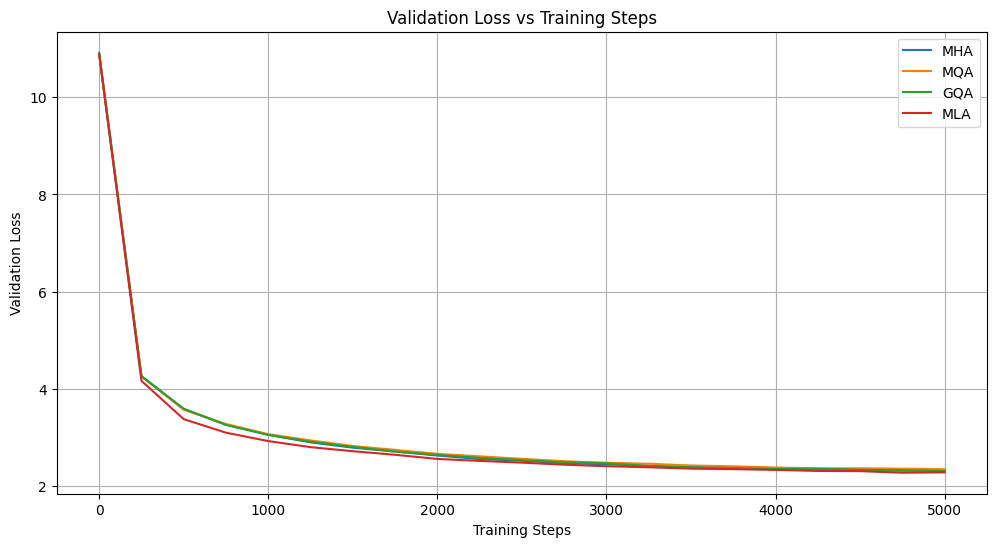

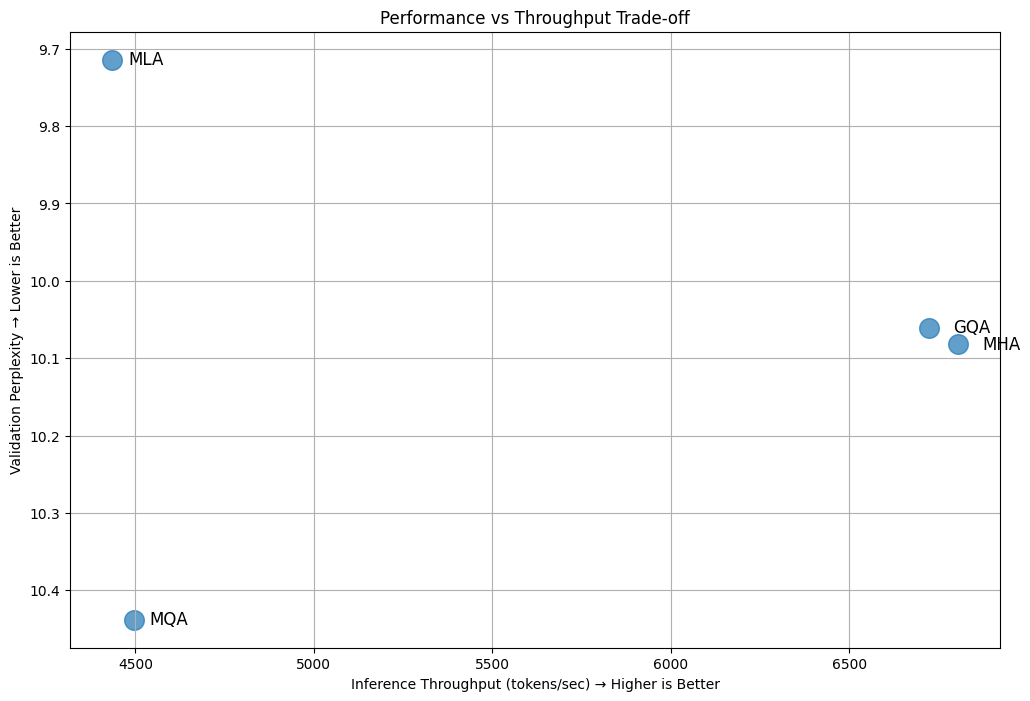

In [26]:
# Create a new figure
plt.figure(
    figsize=(12, 6)
)

# Plot validation loss for each model
for model_name, row in df_results.iterrows():

    # Validation loss recorded during training
    val_loss_history = row[
        "val_loss_history"
    ]

    # Create x-axis values
    #
    # Example:
    # 0, 250, 500, ...
    steps = [

        i * EVAL_INTERVAL

        for i in range(
            len(val_loss_history)
        )
    ]

    # Plot validation loss curve
    plt.plot(

        steps,

        val_loss_history,

        label=model_name
    )

# Add chart title
plt.title(
    "Validation Loss vs Training Steps"
)

# Label x-axis
plt.xlabel(
    "Training Steps"
)

# Label y-axis
plt.ylabel(
    "Validation Loss"
)

# Display model legend
plt.legend()

# Add grid lines
plt.grid(True)

# Display figure
plt.show()


# ============================================================
# Topic: Plot 2 - Performance vs Throughput Trade-off
# ============================================================

# Create a new figure
plt.figure(
    figsize=(12, 8)
)

# ------------------------------------------------------------
# Define Axes
# ------------------------------------------------------------

# X-axis:
# Higher throughput is better
x_axis = df_final_summary[
    "throughput_tok_per_sec"
]

# Y-axis:
# Lower perplexity is better
y_axis = df_final_summary[
    "best_val_perplexity"
]

# ------------------------------------------------------------
# Create Scatter Plot
# ------------------------------------------------------------

plt.scatter(

    x_axis,

    y_axis,

    # Marker size
    s=200,

    # Transparency
    alpha=0.7
)

# ------------------------------------------------------------
# Label Each Model
# ------------------------------------------------------------

for model_name, (
    x,
    y
) in df_final_summary[
    [
        "throughput_tok_per_sec",
        "best_val_perplexity"
    ]
].iterrows():

    plt.text(

        # Slight horizontal offset
        x * 1.01,

        y,

        model_name,

        fontsize=12,

        verticalalignment="center"
    )

# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

# Chart title
plt.title(
    "Performance vs Throughput Trade-off"
)

# X-axis label
plt.xlabel(
    "Inference Throughput (tokens/sec) → Higher is Better"
)

# Y-axis label
plt.ylabel(
    "Validation Perplexity → Lower is Better"
)

# Add grid lines
plt.grid(True)

# ------------------------------------------------------------
# Invert Y-axis
# ------------------------------------------------------------
#
# Lower perplexity is better.
#
# By inverting the axis:
#
# Top-right corner
# = Best Quality + Best Speed
plt.gca().invert_yaxis()

# Display figure
plt.show()

# Detailed Parameter Breakdown Analysis

In [27]:
# Import pandas for tabular analysis
import pandas as pd

# ------------------------------------------------------------
# Function: Parameter Breakdown
# ------------------------------------------------------------

# Calculates how parameters are distributed across
# different components of the GPT model.
def get_parameter_breakdown(model):

    # Dictionary to store parameter counts
    params = {

        # Token and positional embeddings
        "Embeddings": 0,

        # Attention mechanism parameters
        "Attention Layers": 0,

        # Feed-Forward Network (MLP) parameters
        "MLP Layers": 0,

        # LayerNorm and output head parameters
        "Final LayerNorm & Head": 0
    }

    # --------------------------------------------------------
    # Inspect Every Trainable Parameter
    # --------------------------------------------------------

    for name, p in model.named_parameters():

        # ----------------------------------------------------
        # Embedding Parameters
        # ----------------------------------------------------
        #
        # Includes:
        # - Token embeddings (wte)
        # - Positional embeddings (wpe)
        if (
            "wte" in name
            or
            "wpe" in name
        ):

            params["Embeddings"] += (
                p.numel()
            )

        # ----------------------------------------------------
        # Attention Parameters
        # ----------------------------------------------------
        #
        # Includes:
        # - MHA
        # - MQA
        # - GQA
        # - MLA
        elif "attn" in name:

            params["Attention Layers"] += (
                p.numel()
            )

        # ----------------------------------------------------
        # Feed Forward Network Parameters
        # ----------------------------------------------------
        elif "mlp" in name:

            params["MLP Layers"] += (
                p.numel()
            )

        # ----------------------------------------------------
        # LayerNorm + LM Head Parameters
        # ----------------------------------------------------
        elif (
            "ln" in name
            or
            "lm_head" in name
        ):

            params[
                "Final LayerNorm & Head"
            ] += p.numel()

    # --------------------------------------------------------
    # Remove Double Counting
    # --------------------------------------------------------
    #
    # GPT uses weight tying:
    #
    # wte.weight == lm_head.weight
    #
    # Therefore subtract once to avoid
    # counting the same parameters twice.
    params[
        "Final LayerNorm & Head"
    ] -= (
        model.transformer.wte.weight.numel()
    )

    # Return parameter breakdown
    return params


# Models to Analyze

# Define attention architectures
models_to_analyze = {

    # Standard Multi-Head Attention
    "MHA": MultiHeadAttention,

    # Multi-Query Attention
    "MQA": MultiQueryAttention,

    # Grouped-Query Attention
    "GQA": GroupedQueryAttention,

    # DeepSeek Multi-Head Latent Attention
    "MLA": MLAAttention,
}

# Dictionary to store results
breakdown_data = {}

print(
    "--- Calculating Detailed "
    "Parameter Breakdown ---"
)

# Analyze Each Architecture

for name, attn_class in models_to_analyze.items():

    # Create model on CPU
    model = GPT(
        BASE_CONFIG,
        attn_class
    ).to("cpu")

    # Compute parameter breakdown
    breakdown_data[name] = (
        get_parameter_breakdown(model)
    )

# Create Summary Table
# Convert results to DataFrame
df_breakdown = pd.DataFrame(
    breakdown_data
).T

# Calculate total parameters
df_breakdown[
    "Total Parameters"
] = df_breakdown.sum(
    axis=1
)

# Display formatted table
display(
    df_breakdown.style.format(
        "{:,.0f}"
    )
)

--- Calculating Detailed Parameter Breakdown ---


,Embeddings,Attention Layers,MLP Layers,Final LayerNorm & Head,Total Parameters
MHA,"12,931,328","1,572,864","3,145,728","-12,862,464","4,787,456"
MQA,"12,931,328","884,736","3,145,728","-12,862,464","4,099,328"
GQA,"12,931,328","1,179,648","3,145,728","-12,862,464","4,394,240"
MLA,"12,865,792","1,376,256","3,145,728","-12,862,464","4,525,312"
